# MNIST Neural Network From Scratch

Build a `784 -> 128 -> 10` neural network from scratch with NumPy, then implement the same architecture with PyTorch for comparison.

## 1. Data preparation

MNIST contains grayscale images with shape `28 x 28`. Pixel values are converted from integers in `[0, 255]` to `float32` values in `[0, 1]`, then each image is flattened into a vector of length `784`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import MNIST

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

### Load MNIST

`download=True` downloads the dataset only when it is not already available in `data/`.

In [2]:
train_dataset = MNIST(root=DATA_DIR, train=True, download=True)
test_dataset = MNIST(root=DATA_DIR, train=False, download=True)

X_train_images = train_dataset.data.numpy()
y_train = train_dataset.targets.numpy()
X_test_images = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

### Normalize and flatten

The model expects one row per example and one column per input feature, so `(28, 28)` images become vectors with `28 * 28 = 784` values.

In [3]:
X_train = X_train_images.reshape(-1, 28 * 28).astype(np.float32) / 255.0
X_test = X_test_images.reshape(-1, 28 * 28).astype(np.float32) / 255.0

print(f"X_train: {X_train.shape}, dtype={X_train.dtype}")
print(f"y_train: {y_train.shape}, dtype={y_train.dtype}")
print(f"X_test:  {X_test.shape}, dtype={X_test.dtype}")
print(f"y_test:  {y_test.shape}, dtype={y_test.dtype}")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

X_train: (60000, 784), dtype=float32
y_train: (60000,), dtype=int64
X_test:  (10000, 784), dtype=float32
y_test:  (10000,), dtype=int64
Pixel range: [0.0, 1.0]


In [4]:
assert X_train.shape == (60_000, 784)
assert X_test.shape == (10_000, 784)
assert y_train.shape == (60_000,)
assert y_test.shape == (10_000,)
assert 0.0 <= X_train.min() and X_train.max() <= 1.0

### Sample images

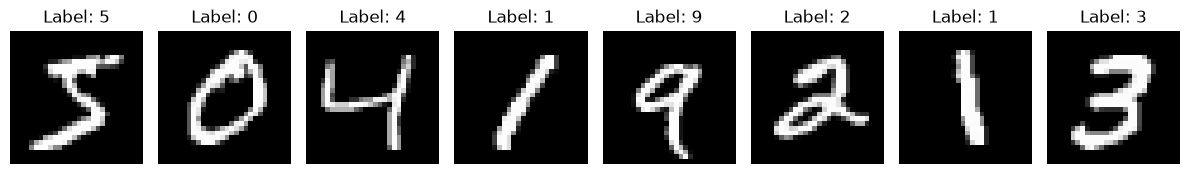

In [5]:
num_samples = 8
fig, axes = plt.subplots(1, num_samples, figsize=(12, 2))

for index, ax in enumerate(axes):
    ax.imshow(X_train[index].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y_train[index]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. NumPy forward pass

The network uses the architecture 784 -> 128 -> 10:

- Input: $X$ with shape (batch_size, 784)
- Hidden layer: $Z_1 = XW_1 + b_1$, followed by $A_1 = ReLU(Z_1)$
- Output layer: $Z_2 = A_1W_2 + b_2$, followed by softmax probabilities

Weights use He initialization, which is a good default for layers followed by ReLU.

In [6]:
def initialize_parameters(input_size=784, hidden_size=128, output_size=10, seed=42):
    rng = np.random.default_rng(seed)

    W1 = (rng.standard_normal((input_size, hidden_size)) * np.sqrt(2.0 / input_size)).astype(np.float32)
    b1 = np.zeros((1, hidden_size), dtype=np.float32)
    W2 = (rng.standard_normal((hidden_size, output_size)) * np.sqrt(2.0 / hidden_size)).astype(np.float32)
    b2 = np.zeros((1, output_size), dtype=np.float32)

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

In [7]:
def linear(X, W, b):
    return X @ W + b


def relu(Z):
    return np.maximum(0, Z)


def softmax(logits):
    shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(shifted_logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

### Forward propagation and loss

Subtracting the largest logit before softmax prevents numerical overflow without changing the probabilities. Cross-entropy uses the predicted probability assigned to each example's correct class.

In [8]:
def forward(X, parameters):
    Z1 = linear(X, parameters["W1"], parameters["b1"])
    A1 = relu(Z1)
    Z2 = linear(A1, parameters["W2"], parameters["b2"])
    probabilities = softmax(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2}
    return probabilities, cache


def cross_entropy_loss(probabilities, y):
    num_samples = y.shape[0]
    correct_class_probabilities = probabilities[np.arange(num_samples), y]
    correct_class_probabilities = np.clip(correct_class_probabilities, 1e-12, 1.0)
    return -np.mean(np.log(correct_class_probabilities))

### Shape checks and sanity test

A five-example batch is enough to verify all parameter and activation shapes, probability sums, and that the initial loss is finite.

In [9]:
parameters = initialize_parameters()
sanity_X = X_train[:5]
sanity_y = y_train[:5]

sanity_probabilities, sanity_cache = forward(sanity_X, parameters)
sanity_loss = cross_entropy_loss(sanity_probabilities, sanity_y)

print("Parameter shapes:")
for name, value in parameters.items():
    print(f"  {name}: {value.shape}")

print("\nForward-pass shapes:")
print(f"  X:             {sanity_X.shape}")
print(f"  Z1 / A1:       {sanity_cache['Z1'].shape}")
print(f"  Z2:            {sanity_cache['Z2'].shape}")
print(f"  probabilities: {sanity_probabilities.shape}")
print(f"Probability row sums: {sanity_probabilities.sum(axis=1)}")
print(f"Initial loss: {sanity_loss:.4f}")

assert parameters["W1"].shape == (784, 128)
assert parameters["b1"].shape == (1, 128)
assert parameters["W2"].shape == (128, 10)
assert parameters["b2"].shape == (1, 10)
assert sanity_cache["Z1"].shape == (5, 128)
assert sanity_cache["A1"].shape == (5, 128)
assert sanity_cache["Z2"].shape == (5, 10)
assert sanity_probabilities.shape == (5, 10)
assert np.allclose(sanity_probabilities.sum(axis=1), 1.0)
assert np.isfinite(sanity_loss)

Parameter shapes:
  W1: (784, 128)
  b1: (1, 128)
  W2: (128, 10)
  b2: (1, 10)

Forward-pass shapes:
  X:             (5, 784)
  Z1 / A1:       (5, 128)
  Z2:            (5, 10)
  probabilities: (5, 10)
Probability row sums: [0.99999994 1.0000001  1.0000001  1.         0.99999994]
Initial loss: 2.7823


## 3. NumPy backpropagation

For a batch of $m$ examples, let $P$ be the softmax probabilities and $Y$ the one-hot labels. The main gradients are:

- Output layer: $dZ_2 = (P - Y) / m$
- Second linear layer: $dW_2 = A_1^T dZ_2$ and $db_2 = sum_{rows}(dZ_2)$
- Backpropagate to the hidden activations: $dA_1 = dZ_2 W_2^T$
- ReLU: $dZ_1 = dA_1 \odot 1[Z_1 > 0]$
- First linear layer: $dW_1 = X^T dZ_1$ and $db_1 = sum_{rows}(dZ_1)$

The division by $m$ matches the mean used by cross-entropy loss. In code, subtracting 1 only at each correct-class position computes $P - Y$ without building a full one-hot matrix.

In [10]:
def backward(X, y, parameters, cache, probabilities):
    num_samples = X.shape[0]

    # Softmax and cross-entropy gradient
    dZ2 = probabilities.copy()
    dZ2[np.arange(num_samples), y] -= 1
    dZ2 /= num_samples

    # Output layer gradients
    dW2 = cache["A1"].T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer and ReLU gradients
    dA1 = dZ2 @ parameters["W2"].T
    dZ1 = dA1 * (cache["Z1"] > 0)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

### Gradient shape checks

Backpropagation is run on the same five-example sanity batch. Each gradient must match the shape of its corresponding parameter and contain only finite values.

In [11]:
sanity_gradients = backward(
    sanity_X, sanity_y, parameters, sanity_cache, sanity_probabilities
)

expected_gradient_shapes = {
    "dW1": parameters["W1"].shape,
    "db1": parameters["b1"].shape,
    "dW2": parameters["W2"].shape,
    "db2": parameters["b2"].shape,
}

for name, gradient in sanity_gradients.items():
    print(f"{name}: shape={gradient.shape}, norm={np.linalg.norm(gradient):.4f}")
    assert gradient.shape == expected_gradient_shapes[name]
    assert np.all(np.isfinite(gradient))

dW1: shape=(784, 128), norm=4.0802
db1: shape=(1, 128), norm=0.4086
dW2: shape=(128, 10), norm=1.5832
db2: shape=(1, 10), norm=0.3437


## 4. NumPy training loop

Training uses mini-batch SGD and a new random permutation of the training data at the start of every epoch. The displayed loss and accuracy are running, sample-weighted metrics computed from batches already processed in the current epoch; no extra full-dataset forward pass is performed per batch.

In [12]:
from tqdm.auto import tqdm


def train_numpy_model(
    X,
    y,
    parameters,
    learning_rate=0.1,
    batch_size=128,
    epochs=10,
    seed=42,
):
    if learning_rate <= 0:
        raise ValueError("learning_rate must be positive")

    if batch_size <= 0:
        raise ValueError("batch_size must be positive")

    if epochs <= 0:
        raise ValueError("epochs must be positive")

    if X.shape[0] != y.shape[0]:
        raise ValueError("X and y must contain the same number of examples")

    num_samples = X.shape[0]
    rng = np.random.default_rng(seed)

    history = {
        "loss": [],
        "accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        shuffled_indices = rng.permutation(num_samples)

        running_loss = 0.0
        running_correct = 0
        processed_samples = 0

        batch_starts = range(0, num_samples, batch_size)

        progress = tqdm(
            batch_starts,
            desc=f"Epoch {epoch}/{epochs}",
            unit="batch",
            leave=True,
        )

        for start in progress:
            batch_indices = shuffled_indices[start:start + batch_size]

            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            # Forward pass
            probabilities, cache = forward(X_batch, parameters)

            # Loss
            batch_loss = cross_entropy_loss(
                probabilities,
                y_batch,
            )

            # Backpropagation
            gradients = backward(
                X_batch,
                y_batch,
                parameters,
                cache,
                probabilities,
            )

            # SGD update
            for parameter_name in ("W1", "b1", "W2", "b2"):
                parameters[parameter_name] -= (
                    learning_rate
                    * gradients[f"d{parameter_name}"]
                )

            # Running metrics
            current_batch_size = y_batch.shape[0]

            running_loss += batch_loss * current_batch_size

            predictions = np.argmax(
                probabilities,
                axis=1,
            )

            running_correct += np.sum(
                predictions == y_batch
            )

            processed_samples += current_batch_size

            running_avg_loss = (
                running_loss / processed_samples
            )

            running_accuracy = (
                running_correct / processed_samples
            )

            progress.set_postfix(
                loss=f"{running_avg_loss:.4f}",
                acc=f"{running_accuracy:.2%}",
                lr=f"{learning_rate:.4f}",
            )

        epoch_loss = running_loss / num_samples
        epoch_accuracy = running_correct / num_samples

        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_accuracy)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"loss={epoch_loss:.4f} | "
            f"accuracy={epoch_accuracy:.2%} | "
            f"lr={learning_rate:.4f}"
        )

    return parameters, history

/home/viethoan/Code/Projects/MNIST/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Train on MNIST

The seed controls both parameter initialization and epoch shuffling, making this run reproducible.

In [13]:
LEARNING_RATE = 0.1
BATCH_SIZE = 128
EPOCHS = 10
TRAINING_SEED = 42

parameters = initialize_parameters(seed=TRAINING_SEED)
parameters, training_history = train_numpy_model(
    X_train,
    y_train,
    parameters,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    seed=TRAINING_SEED,
)

assert len(training_history["loss"]) == EPOCHS
assert len(training_history["accuracy"]) == EPOCHS
assert np.all(np.isfinite(training_history["loss"]))
assert np.all(np.isfinite(training_history["accuracy"]))

Epoch 01/10 | loss=0.4582 | accuracy=87.65% | lr=0.1000
Epoch 02/10 | loss=0.2573 | accuracy=92.69% | lr=0.1000
Epoch 03/10 | loss=0.2071 | accuracy=94.16% | lr=0.1000
Epoch 04/10 | loss=0.1753 | accuracy=94.94% | lr=0.1000
Epoch 05/10 | loss=0.1526 | accuracy=95.68% | lr=0.1000
Epoch 06/10 | loss=0.1348 | accuracy=96.21% | lr=0.1000
Epoch 07/10 | loss=0.1207 | accuracy=96.66% | lr=0.1000
Epoch 08/10 | loss=0.1096 | accuracy=96.98% | lr=0.1000
Epoch 09/10 | loss=0.0999 | accuracy=97.27% | lr=0.1000
Epoch 10/10 | loss=0.0925 | accuracy=97.44% | lr=0.1000
